In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set(style="whitegrid")

In [2]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

plt.rcParams.update({
'figure.figsize': (10, 5),
'grid.color': '#dddddd',
'grid.linestyle': '--',
'axes.grid': True,
})

df = pd.read_csv(r'C:\Users\prati\Downloads\sales_data_with_discounts.csv')

In [3]:
print("DataFrame shape:", df.shape)
display(df.head())
print('\nDataFrame info:')
df.info()

DataFrame shape: (450, 13)


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [4]:
df.describe()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


In [5]:
df.dtypes

Date                  object
Day                   object
SKU                   object
City                  object
Volume                 int64
BU                    object
Brand                 object
Model                 object
Avg Price              int64
Total Sales Value      int64
Discount Rate (%)    float64
Discount Amount      float64
Net Sales Value      float64
dtype: object

In [6]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
print(numeric_columns)
print(categorical_columns)

['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']
['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


In [7]:
summary = pd.DataFrame(index=numeric_columns, columns=['mean','median','std','mode'])

for c in numeric_columns:
    series = df[c].dropna()
    mean_v = series.mean()
    median_v = series.median()
    std_v = series.std()
    modes = series.mode()
    if len(modes) == 0:
        mode_val = np.nan
    elif len(modes) == 1:
        mode_val = modes.iloc[0]
    else:
        mode_val = ', '.join(map(str, modes.values))
    summary.loc[c] = [mean_v, median_v, std_v, mode_val]
summary[['mean','median','std']] = summary[['mean','median','std']].astype(float)
print("Descriptive statistics for numerical columns:")
display(summary)

Descriptive statistics for numerical columns:


,mean,median,std,mode
Volume,5.066667,4.000000,4.231602,3
Avg Price,10453.433333,1450.000000,18079.904840,"400, 450, 500, 1300, 8100"
Total Sales Value,33812.835556,5700.000000,50535.074173,24300
Discount Rate (%),15.155242,16.577766,4.220602,"5.007822189204133, 5.055218412429214, 5.059801..."
Discount Amount,3346.499424,988.933733,4509.902963,"69.17794228822787, 73.02519944529182, 93.64916..."
Net Sales Value,30466.336131,4677.788059,46358.656624,"326.97480055470817, 330.8220577117721, 466.350..."


In [8]:
num_columns = df.select_dtypes(include=['int64', 'float64']).columns
cat_columns = df.select_dtypes(include=["object"]).columns
mean_value = df[num_columns].mean()
print("Mean \n",mean_value)
median_value = df[num_columns].median()
print("Median \n",median_value)
mode_value = df[num_columns].mode()
print("Mode \n",mode_value)
mode_value_1 = df[num_columns].mode().iloc[0]
print("Mode_1 \n",mode_value_1)
std_value = df[num_columns].std()
print("Std Deviation \n",std_value)

Mean 
 Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64
Median 
 Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64
Mode 
      Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  Net Sales Value
0       3.0      400.0            24300.0           5.007822        69.177942       326.974801
1       NaN      450.0                NaN           5.055218        73.025199       330.822058
2       NaN      500.0                NaN           5.059801        93.649161       466.350839
3       NaN     1300.0                NaN           5.072124        94.682735       485.317265
4       NaN     8100.0                NaN           5.084108       102

In [9]:
interpretation = """
Interpretation:

- Volume has a relatively low average and median, indicating that most transactions involve small quantities.
- Price-based measures (Avg Price, Sales, Discounts) have high standard deviations, showing high variability and the presence of both premium and low-cost items.
- Discount Rate is moderately centered around 15–17%, but outliers exist on the lower side (5–7%).
- Sales Value and Net Sales Value are right-skewed, with many low-value sales and a few very high-value sales.

    *Median is more meaningful than mean
    *Mode is only useful for categorical variables
    *Mean is still useful, but should be interpreted carefully due to outliers

->Volume -> moderate Std Deviation -> normal variation in quantity sold
->Avg Price, Total Sales, Net Sales -> very high Std Deviation
    -- indicates strong skewness
    -- suggests multiple product categories
    -- confirms outliers in higher-priced items
"""

print(interpretation)


Interpretation:

- Volume has a relatively low average and median, indicating that most transactions involve small quantities.
- Price-based measures (Avg Price, Sales, Discounts) have high standard deviations, showing high variability and the presence of both premium and low-cost items.
- Discount Rate is moderately centered around 15–17%, but outliers exist on the lower side (5–7%).
- Sales Value and Net Sales Value are right-skewed, with many low-value sales and a few very high-value sales.

    *Median is more meaningful than mean
    *Mode is only useful for categorical variables
    *Mean is still useful, but should be interpreted carefully due to outliers

->Volume -> moderate Std Deviation -> normal variation in quantity sold
->Avg Price, Total Sales, Net Sales -> very high Std Deviation
    -- indicates strong skewness
    -- suggests multiple product categories
    -- confirms outliers in higher-priced items



In [10]:
def interpret_numeric(series: pd.Series) -> str:
    s = series.dropna()
    skew = s.skew()
    coef_var = s.std() / (s.mean() if s.mean() != 0 else 1)
    i = []
    
    
    # skewness interpretation
    if skew > 1:
        i.append('strong right skew (long tail on the high side)')
    elif skew > 0.5:
        i.append('moderate right skew')
    elif skew < -1:
        i.append('strong left skew')
    elif skew < -0.5:
        i.append('moderate left skew')
    else:
        i.append('approximately symmetric')
    
    
    # variation interpretation
    if coef_var > 1:
        i.append('high relative variability (std > mean)')
    elif coef_var > 0.5:
        i.append('moderate variability')
    else:
        i.append('low relative variability')
    
    
    # outlier presence quick check using IQR
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr
    lower_fence = q1 - 1.5 * iqr
    outliers = s[(s > upper_fence) | (s < lower_fence)]
    if len(outliers) > 0:
        i.append(f'{len(outliers)} potential outlier(s) detected via IQR rule')
    else:
        i.append('no major IQR outliers detected')
    
    
    return '; '.join(i)
    
    
    # print interpretations for each numeric column
print('Quick interpretations:')
for c in numeric_columns:
    print(f"- {c}: {interpret_numeric(df[c])}")

Quick interpretations:
- Volume: strong right skew (long tail on the high side); moderate variability; 44 potential outlier(s) detected via IQR rule
- Avg Price: strong right skew (long tail on the high side); high relative variability (std > mean); 60 potential outlier(s) detected via IQR rule
- Total Sales Value: strong right skew (long tail on the high side); high relative variability (std > mean); 36 potential outlier(s) detected via IQR rule
- Discount Rate (%): strong left skew; low relative variability; 45 potential outlier(s) detected via IQR rule
- Discount Amount: strong right skew (long tail on the high side); high relative variability (std > mean); 24 potential outlier(s) detected via IQR rule
- Net Sales Value: strong right skew (long tail on the high side); high relative variability (std > mean); 35 potential outlier(s) detected via IQR rule


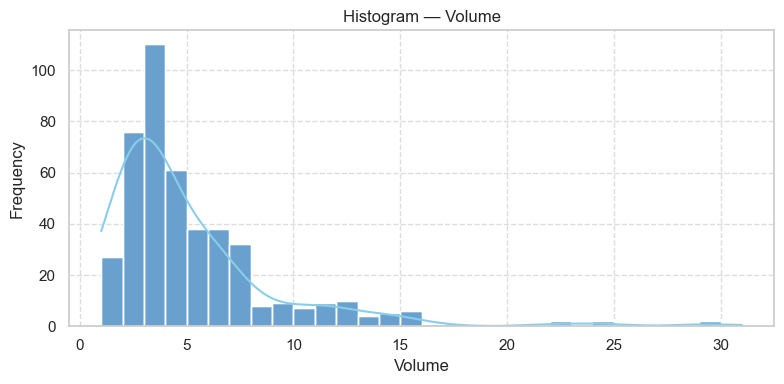

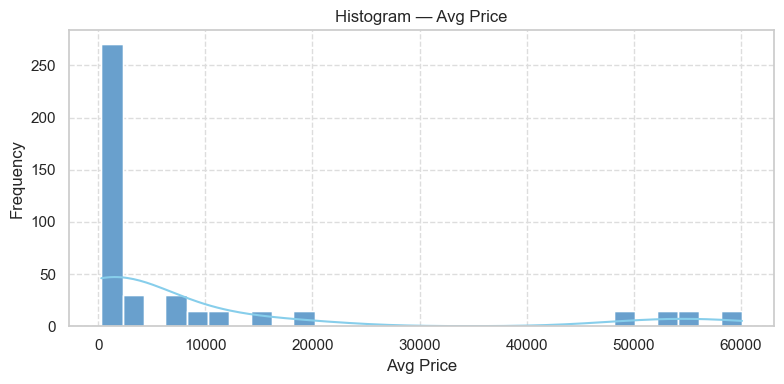

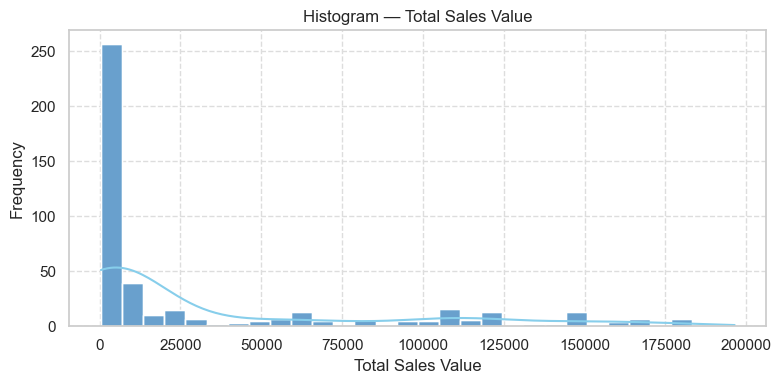

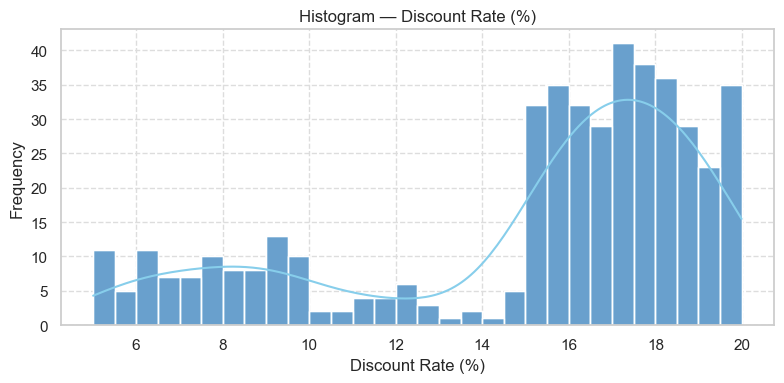

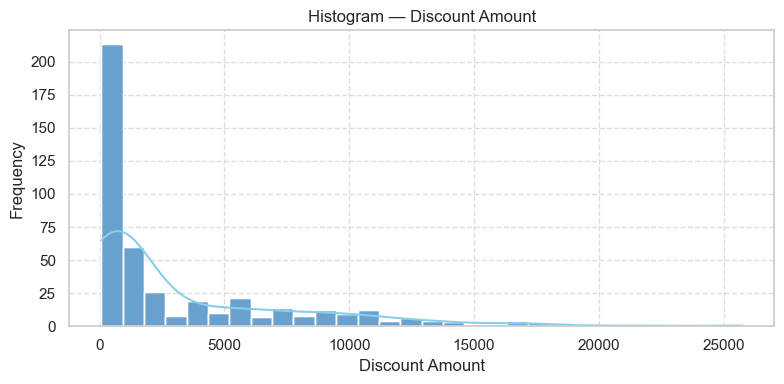

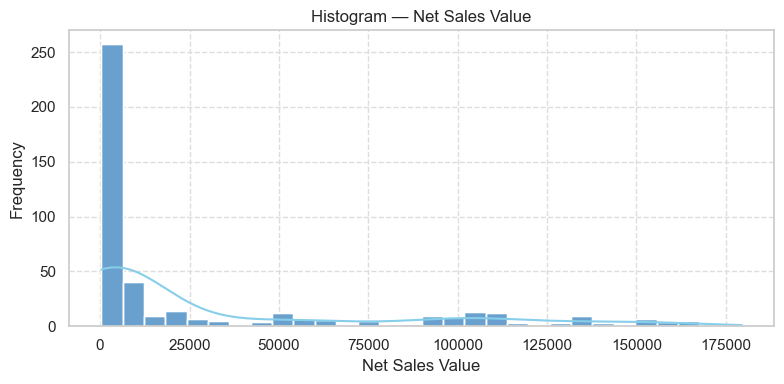

In [11]:
for c in numeric_columns:
    plt.figure(figsize=(8,4))
    plt.hist(df[c].dropna(), bins=30)
    sns.histplot(df[c], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram — {c}')
    plt.xlabel(c)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [12]:
Histogram_Analysis = """
->Volume
    --Right-skewed distribution. 
    --Most transactions involve 1–6 units.
    --A few extreme values (20–30 units) appear as outliers.

->Avg Price
    --Strong right skew.
    --Majority prices lie on the lower end (< ₹10,000), with some premium items reaching ₹60,000.

->Sales & Discount Values
   --Very skewed distributions—majority of values are small, with a few very large outliers.
   --Indicates wide variation in product categories (FMCG vs. Mobiles/Lifestyle).
"""
print(Histogram_Analysis)


->Volume
    --Right-skewed distribution. 
    --Most transactions involve 1–6 units.
    --A few extreme values (20–30 units) appear as outliers.

->Avg Price
    --Strong right skew.
    --Majority prices lie on the lower end (< ₹10,000), with some premium items reaching ₹60,000.

->Sales & Discount Values
   --Very skewed distributions—majority of values are small, with a few very large outliers.
   --Indicates wide variation in product categories (FMCG vs. Mobiles/Lifestyle).



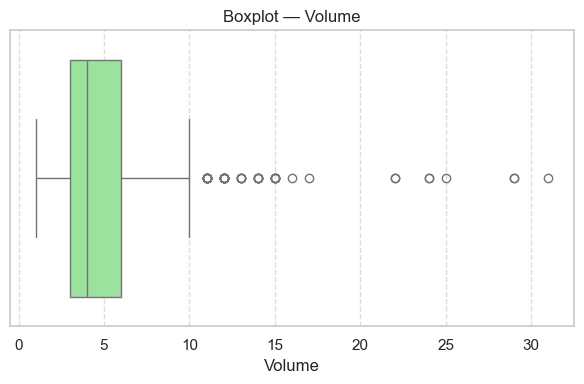

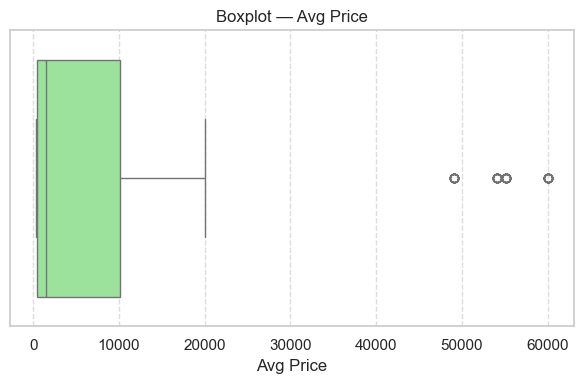

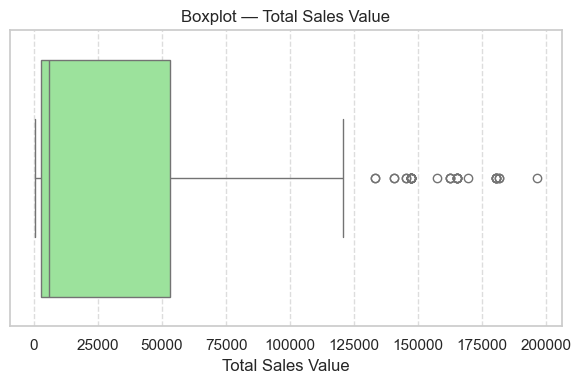

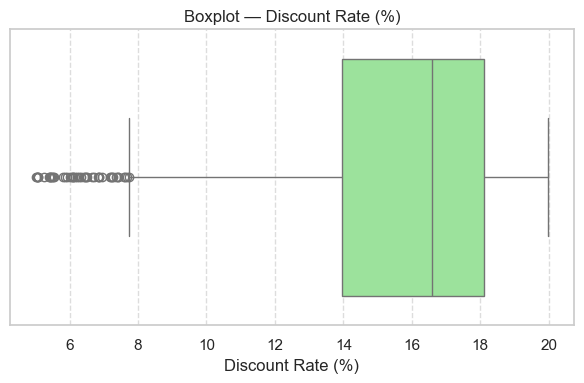

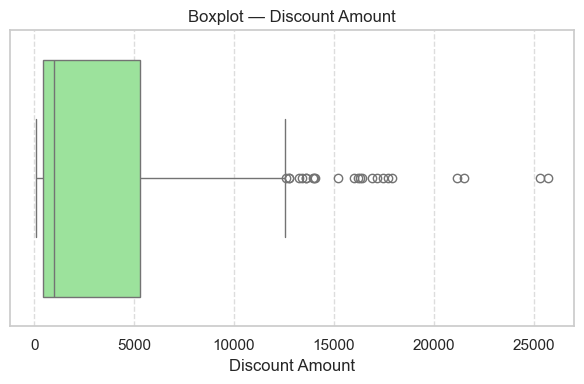

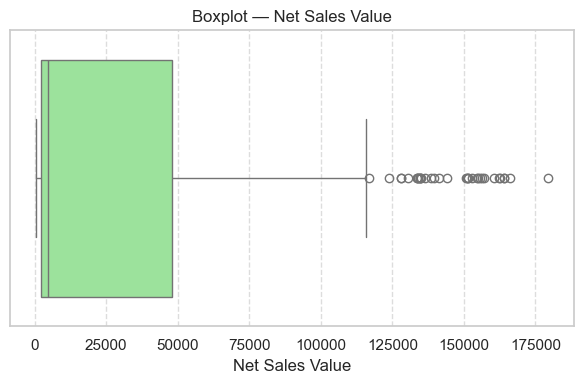

In [13]:
for c in numeric_columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[c].dropna(), vert=False)
    sns.boxplot(x=df[c], color='lightgreen')
    plt.xlabel(c)
    plt.title(f'Boxplot — {c}')
    plt.tight_layout()
    plt.show()

In [14]:
BoxPlot_Analysis = """
Outliers are present, especially in:
    --Avg Price
   --Total Sales Value
    --Net Sales Value
    --Discount Amount
The presence of heavy upper whiskers confirms right-skewness.
Discount Rate shows lower-end outliers, meaning certain SKUs have very small discount percentages.
"""
print(BoxPlot_Analysis)


Outliers are present, especially in:
    --Avg Price
   --Total Sales Value
    --Net Sales Value
    --Discount Amount
The presence of heavy upper whiskers confirms right-skewness.
Discount Rate shows lower-end outliers, meaning certain SKUs have very small discount percentages.



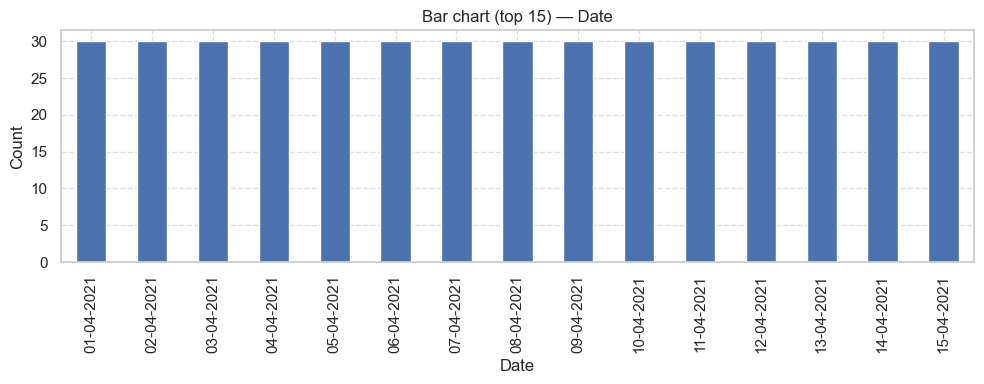

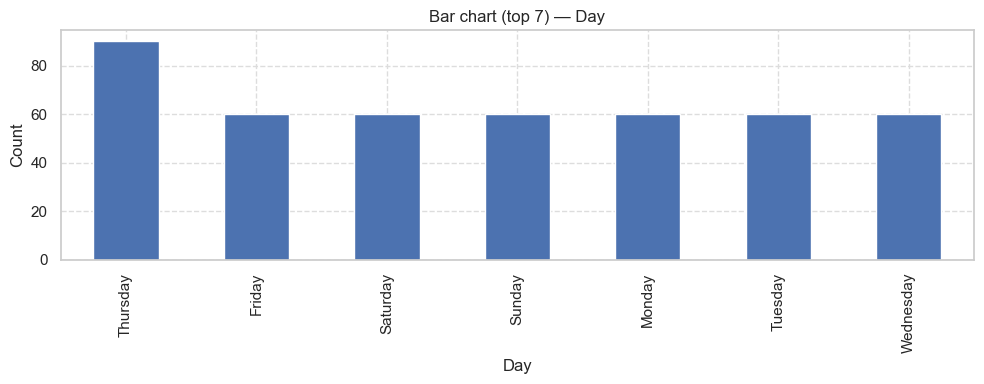

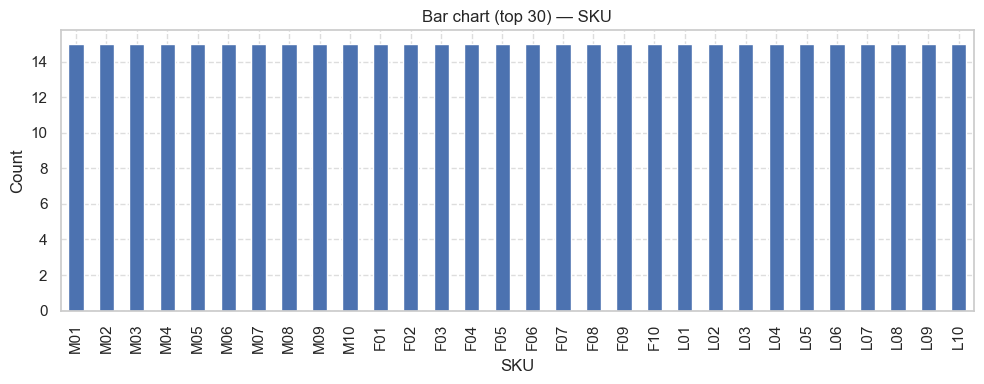

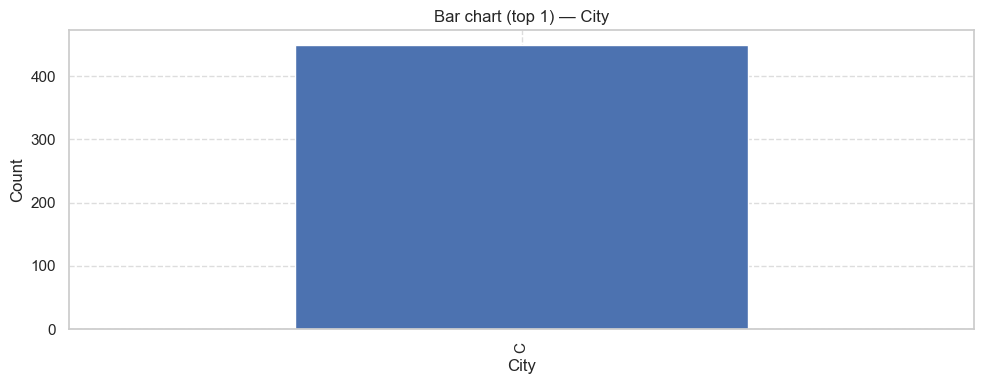

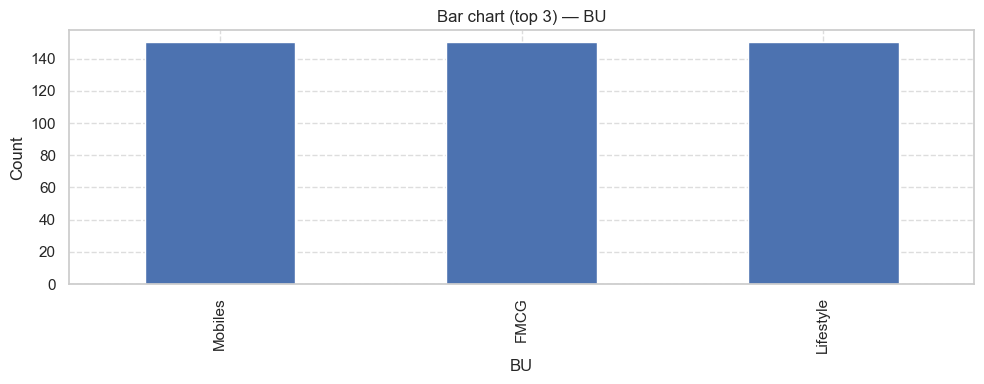

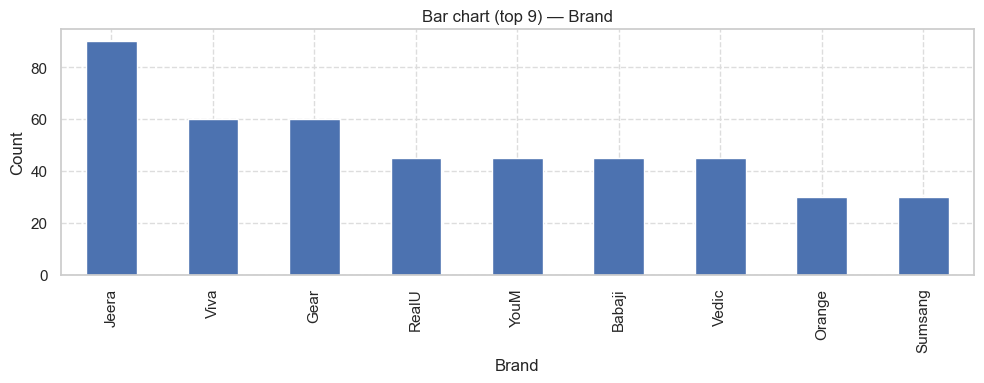

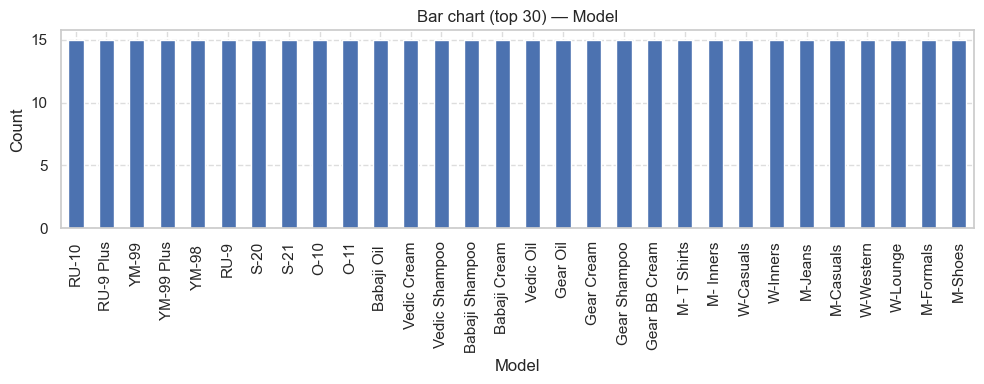

In [15]:
for c in categorical_columns:
    vc = df[c].value_counts()
    top_n = 30
    if len(vc) > top_n:
        vc = vc.iloc[:top_n]
    
    
    plt.figure(figsize=(10,4))
    vc.plot(kind='bar')
    plt.title(f'Bar chart (top {min(top_n, len(df[c].unique()))}) — {c}')
    plt.xlabel(c)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

In [16]:
BarChart_Analysis = """
->Date
    --Each date appears exactly 30 times, indicating consistent daily sales volume across the 15-day period.
->Day of Week
    --Thursday shows the highest activity (≈ 90 entries).
    --Other days remain nearly uniform (≈ 60 each).
->SKU
    --Each SKU appears 15 times, suggesting balanced sampling or uniform SKU presence.
->City
    --Only one city present (single value repeated).
    --No cross-city comparison possible.
->BU (Business Unit)
    Three categories exist:
        --Mobiles
        --FMCG
        --Lifestyle
    Each BU appears evenly (~150 counts each).
->Brand & Model
    Brand distribution varies:
        --Jeera brand leads with ~90 counts.
        --Sumsang, Orange lowest (~30 counts).
Model distribution is balanced, with each roughly equal in frequency.
"""
print(BarChart_Analysis)


->Date
    --Each date appears exactly 30 times, indicating consistent daily sales volume across the 15-day period.
->Day of Week
    --Thursday shows the highest activity (≈ 90 entries).
    --Other days remain nearly uniform (≈ 60 each).
->SKU
    --Each SKU appears 15 times, suggesting balanced sampling or uniform SKU presence.
->City
    --Only one city present (single value repeated).
    --No cross-city comparison possible.
->BU (Business Unit)
    Three categories exist:
        --Mobiles
        --FMCG
        --Lifestyle
    Each BU appears evenly (~150 counts each).
->Brand & Model
    Brand distribution varies:
        --Jeera brand leads with ~90 counts.
        --Sumsang, Orange lowest (~30 counts).
Model distribution is balanced, with each roughly equal in frequency.



In [17]:
if 'Brand' in df.columns and 'Total Sales Value' in df.columns:
    brand_sales = df.groupby('Brand')['Total Sales Value'].sum().sort_values(ascending=False)
    print('\nTop 10 brands by total sales:')
    display(brand_sales.head(10))


# average discount rate by business unit (BU)
if 'BU' in df.columns and 'Discount Rate (%)' in df.columns:
    print('\nAverage discount rate by BU:')
    display(df.groupby('BU')['Discount Rate (%)'].mean())


# correlation between Avg Price and Net Sales Value
if 'Avg Price' in df.columns and 'Net Sales Value' in df.columns:
    corr = df['Avg Price'].corr(df['Net Sales Value'])
    print(f'\nCorrelation between Avg Price and Net Sales Value: {corr:.3f}')


Top 10 brands by total sales:


Brand
Orange     3911800
Sumsang    3572000
YouM       3365900
RealU      3070400
Jeera       516469
Viva        382000
Babaji      176090
Vedic       113700
Gear        107417
Name: Total Sales Value, dtype: int64


Average discount rate by BU:


BU
FMCG         17.432604
Lifestyle    17.470720
Mobiles      10.562401
Name: Discount Rate (%), dtype: float64


Correlation between Avg Price and Net Sales Value: 0.841


In [18]:
Key_Findings = """
1. Numerical Insights
    --The dataset exhibits significant right-skewness, particularly in monetary values (price, sales).
    --High variability indicates multiple product tiers—low-priced FMCG items mixed with high-priced mobile products.
    --Several outliers exist, especially among high-priced mobile SKUs.
2. Categorical Insights
    --SKU distribution is balanced → good representation across models.
    --Only one city present → analysis is not geographically diverse.
    --Sales volume across days is consistent, with Thursday being a busier day.
3. Visual Insights
   -- Histograms clearly show skewed distributions.
    --Boxplots confirm outliers across nearly all numerical features.
    --Bar charts highlight which brands dominate and how categories are structured.
"""
print(Key_Findings)


1. Numerical Insights
    --The dataset exhibits significant right-skewness, particularly in monetary values (price, sales).
    --High variability indicates multiple product tiers—low-priced FMCG items mixed with high-priced mobile products.
    --Several outliers exist, especially among high-priced mobile SKUs.
2. Categorical Insights
    --SKU distribution is balanced → good representation across models.
    --Only one city present → analysis is not geographically diverse.
    --Sales volume across days is consistent, with Thursday being a busier day.
3. Visual Insights
   -- Histograms clearly show skewed distributions.
    --Boxplots confirm outliers across nearly all numerical features.
    --Bar charts highlight which brands dominate and how categories are structured.

